<a href="https://colab.research.google.com/github/taha260/DL_Projet_ZAAMI_TAHA/blob/main/Partie_1_MLP_Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Partie I — MLP sur Spotify Tracks Dataset

Notebook séparé pour la **Partie I** du projet de Deep Learning.

Objectif : réaliser une classification supervisée sur des données tabulaires musicales avec un MLP sous PyTorch.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Projet_Deep_Learning_Musique"
os.makedirs(PROJECT_DIR, exist_ok=True)

DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

for folder in [DATA_DIR, MODEL_DIR, RESULTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Dossier projet :", PROJECT_DIR)

Dossier projet : /content/drive/MyDrive/Projet_Deep_Learning_Musique


## 1. Imports et configuration

Cette section importe les bibliothèques nécessaires, fixe une seed pour la reproductibilité et sélectionne automatiquement le GPU si disponible.

In [3]:
import os
import glob
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

required_vars = ["PROJECT_DIR", "DATA_DIR", "MODEL_DIR", "RESULTS_DIR"]
missing_vars = [var for var in required_vars if var not in globals()]

if missing_vars:
    raise NameError(
        "Les variables suivantes doivent déjà exister dans le notebook : "
        + ", ".join(missing_vars)
    )

SPOTIFY_DIR = os.path.join(DATA_DIR, "spotify")
print("Dossier Spotify :", SPOTIFY_DIR)

Device utilisé : cuda
Dossier Spotify : /content/drive/MyDrive/Projet_Deep_Learning_Musique/data/spotify


## 2. Vérification du dataset Spotify

In [4]:
if not os.path.exists(SPOTIFY_DIR):
    raise FileNotFoundError(f"Le dossier Spotify est introuvable : {SPOTIFY_DIR}")

print("Contenu du dossier Spotify :")
for item in os.listdir(SPOTIFY_DIR):
    print("-", item)

csv_files = glob.glob(os.path.join(SPOTIFY_DIR, "*.csv"))

if len(csv_files) == 0:
    raise FileNotFoundError("Aucun fichier CSV trouvé dans le dossier Spotify.")

if len(csv_files) > 1:
    print("\nPlusieurs fichiers CSV trouvés :")
    for file in csv_files:
        print("-", file)

def csv_score(path):
    name = os.path.basename(path).lower()
    score = 0

    if "spotify" in name:
        score += 3
    if "track" in name or "tracks" in name:
        score += 3
    if "dataset" in name:
        score += 1

    size = os.path.getsize(path)
    return score, size

csv_path = sorted(csv_files, key=csv_score, reverse=True)[0]

print("\nFichier CSV sélectionné automatiquement :")
print(csv_path)

df = pd.read_csv(csv_path)

print("\nAperçu des 5 premières lignes :")
display(df.head())

print("\nTaille du dataframe :", df.shape)

print("\nColonnes disponibles :")
print(df.columns.tolist())

print("\nTypes de données :")
display(df.dtypes)

print("\nValeurs manquantes par colonne :")
display(df.isnull().sum())

if "track_genre" in df.columns:
    print("\nDistribution de la colonne cible track_genre :")
    display(df["track_genre"].value_counts())
else:
    print("\nAttention : la colonne cible track_genre n'existe pas dans ce fichier.")

Contenu du dossier Spotify :
- dataset.csv

Fichier CSV sélectionné automatiquement :
/content/drive/MyDrive/Projet_Deep_Learning_Musique/data/spotify/dataset.csv

Aperçu des 5 premières lignes :


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic



Taille du dataframe : (114000, 21)

Colonnes disponibles :
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Types de données :


,0
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64



Valeurs manquantes par colonne :


,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0



Distribution de la colonne cible track_genre :


,count
track_genre,
acoustic,1000
afrobeat,1000
alt-rock,1000
alternative,1000
ambient,1000
...,...
techno,1000
trance,1000
trip-hop,1000


## 3. Préparation des données

In [5]:
target_column = "track_genre"

if target_column not in df.columns:
    raise ValueError(
        "La colonne track_genre est absente. "
        "Impossible de faire une classification supervisée par genre."
    )

top_n_genres = 10
genre_counts = df[target_column].value_counts()

if len(genre_counts) > top_n_genres:
    top_genres = genre_counts.head(top_n_genres).index
    df_work = df[df[target_column].isin(top_genres)].copy()
    print(f"Nombre de genres initial : {len(genre_counts)}")
    print(f"On garde les {top_n_genres} genres les plus fréquents.")
else:
    df_work = df.copy()
    print(f"Nombre de genres : {len(genre_counts)}")

candidate_features = [
    "popularity",
    "duration_ms",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

feature_columns = [col for col in candidate_features if col in df_work.columns]

if len(feature_columns) == 0:
    raise ValueError("Aucune colonne numérique utile n'a été trouvée.")

print("Colonnes utilisées comme features :")
print(feature_columns)

df_model = df_work[feature_columns + [target_column]].copy()
df_model = df_model.dropna(subset=feature_columns + [target_column])

print("Taille après suppression des valeurs manquantes :", df_model.shape)

X = df_model[feature_columns].values
y_text = df_model[target_column].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

num_classes = len(label_encoder.classes_)
input_dim = X.shape[1]

print("Nombre de features :", input_dim)
print("Nombre de classes :", num_classes)
print("Classes :", label_encoder.classes_)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

try:
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_scaled,
        y,
        test_size=0.30,
        random_state=SEED,
        stratify=y
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=SEED,
        stratify=y_temp
    )

except ValueError as error:
    print("Stratification impossible, division sans stratify.")
    print("Message :", error)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X_scaled,
        y,
        test_size=0.30,
        random_state=SEED
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=SEED
    )

print("Train :", X_train.shape, y_train.shape)
print("Validation :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Nombre de genres initial : 114
On garde les 10 genres les plus fréquents.
Colonnes utilisées comme features :
['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
Taille après suppression des valeurs manquantes : (10000, 12)
Nombre de features : 11
Nombre de classes : 10
Classes : ['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient' 'anime'
 'black-metal' 'bluegrass' 'blues' 'brazil']
Train : (7000, 11) (7000,)
Validation : (1500, 11) (1500,)
Test : (1500, 11) (1500,)


In [6]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 64

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders créés avec batch_size =", batch_size)

DataLoaders créés avec batch_size = 64


## 4. Modèles MLP

In [7]:
class MLPSequential(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.model(x)


class MLPCustom(nn.Module):
    # nn.Module est la classe de base pour créer un modèle PyTorch.
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        return x

## 5. Initialisation des poids

In [8]:
def init_weights(model, method="xavier"):
    for module in model.modules():
        if isinstance(module, nn.Linear):
            if method == "gaussian":
                nn.init.normal_(module.weight, mean=0.0, std=0.01)

            elif method == "constant":
                nn.init.constant_(module.weight, 0.01)

            elif method == "xavier":
                nn.init.xavier_uniform_(module.weight)

            else:
                raise ValueError(
                    "Méthode inconnue. Choisir parmi : gaussian, constant, xavier."
                )

            nn.init.constant_(module.bias, 0.0)

    return model

## 6. Fonctions d'entraînement et d'évaluation

In [9]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    for features, labels in dataloader:
        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(features)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)

        predictions = torch.argmax(outputs, dim=1)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)

    return epoch_loss, epoch_accuracy


def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dataloader:
            features = features.to(device)
            labels = labels.to(device)

            outputs = model(features)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * features.size(0)

            predictions = torch.argmax(outputs, dim=1)
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)

    return epoch_loss, epoch_accuracy, np.array(all_predictions), np.array(all_labels)


def plot_training_curves(history, save_path):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Courbe de loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_accuracy"], label="Train accuracy")
    plt.plot(epochs, history["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Courbe d'accuracy")
    plt.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

    print("Courbe sauvegardée :", save_path)

In [10]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=20,
    patience=5,
    save_path=None
):
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    best_val_loss = np.inf
    best_val_accuracy = 0.0
    epochs_without_improvement = 0

    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_accuracy, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Val accuracy: {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_accuracy = val_accuracy
            epochs_without_improvement = 0

            if save_path is not None:
                # On sauvegarde le meilleur modèle pour éviter de garder un modèle moins performant.
                torch.save(model.state_dict(), save_path)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping après {epoch} epochs.")
            break

    return history, best_val_loss, best_val_accuracy

## 7. Expériences comparatives


Expérience : MLPSequential_gaussian
Epoch 01/20 | Train loss: 2.0248 | Val loss: 1.6962 | Val accuracy: 0.3633
Epoch 02/20 | Train loss: 1.6627 | Val loss: 1.5350 | Val accuracy: 0.4420
Epoch 03/20 | Train loss: 1.5371 | Val loss: 1.4116 | Val accuracy: 0.4873
Epoch 04/20 | Train loss: 1.4447 | Val loss: 1.3141 | Val accuracy: 0.5500
Epoch 05/20 | Train loss: 1.3754 | Val loss: 1.2538 | Val accuracy: 0.5680
Epoch 06/20 | Train loss: 1.3304 | Val loss: 1.2060 | Val accuracy: 0.5907
Epoch 07/20 | Train loss: 1.2890 | Val loss: 1.1701 | Val accuracy: 0.5953
Epoch 08/20 | Train loss: 1.2594 | Val loss: 1.1471 | Val accuracy: 0.6013
Epoch 09/20 | Train loss: 1.2503 | Val loss: 1.1354 | Val accuracy: 0.5993
Epoch 10/20 | Train loss: 1.2287 | Val loss: 1.1176 | Val accuracy: 0.6120
Epoch 11/20 | Train loss: 1.2124 | Val loss: 1.1084 | Val accuracy: 0.6033
Epoch 12/20 | Train loss: 1.1912 | Val loss: 1.0918 | Val accuracy: 0.6233
Epoch 13/20 | Train loss: 1.1913 | Val loss: 1.0868 | Val accur

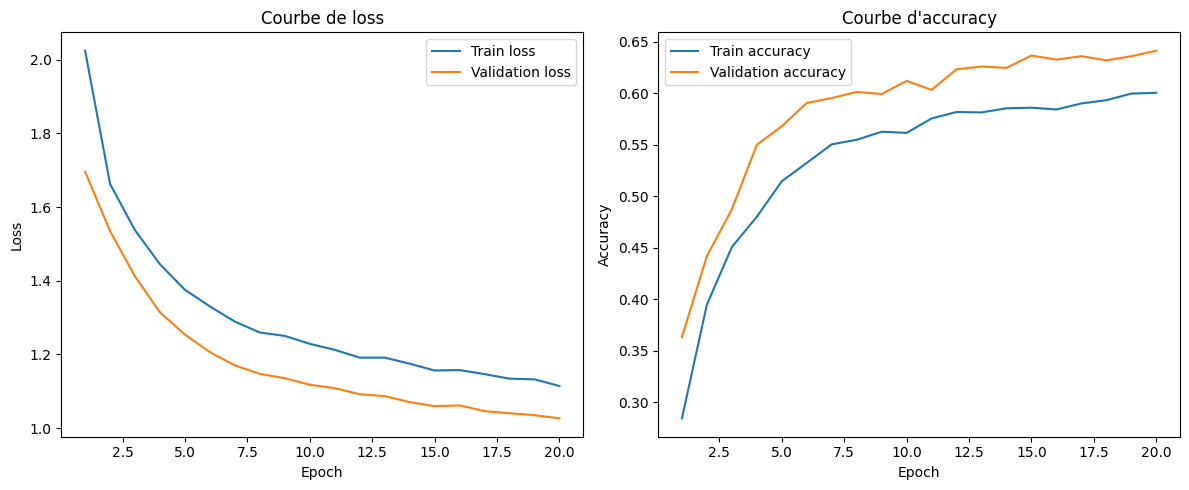

Courbe sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/MLPSequential_gaussian_curves.png

Expérience : MLPSequential_constant
Epoch 01/20 | Train loss: 2.2264 | Val loss: 2.1798 | Val accuracy: 0.1920
Epoch 02/20 | Train loss: 2.1695 | Val loss: 2.1328 | Val accuracy: 0.2360
Epoch 03/20 | Train loss: 2.0760 | Val loss: 2.0117 | Val accuracy: 0.2747
Epoch 04/20 | Train loss: 1.9717 | Val loss: 1.8787 | Val accuracy: 0.3480
Epoch 05/20 | Train loss: 1.7977 | Val loss: 1.6353 | Val accuracy: 0.4807
Epoch 06/20 | Train loss: 1.5667 | Val loss: 1.3525 | Val accuracy: 0.5553
Epoch 07/20 | Train loss: 1.3951 | Val loss: 1.2458 | Val accuracy: 0.5647
Epoch 08/20 | Train loss: 1.3399 | Val loss: 1.2067 | Val accuracy: 0.5820
Epoch 09/20 | Train loss: 1.3065 | Val loss: 1.1818 | Val accuracy: 0.5927
Epoch 10/20 | Train loss: 1.2728 | Val loss: 1.1573 | Val accuracy: 0.5927
Epoch 11/20 | Train loss: 1.2547 | Val loss: 1.1380 | Val accuracy: 0.6020
Epoch 12/20 | Train los

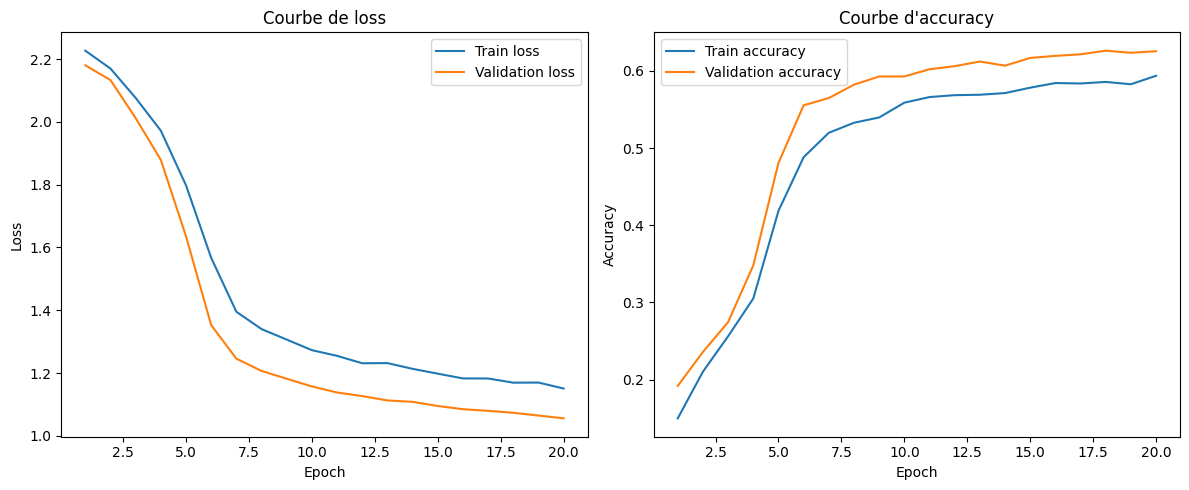

Courbe sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/MLPSequential_constant_curves.png

Expérience : MLPSequential_xavier
Epoch 01/20 | Train loss: 1.9345 | Val loss: 1.5665 | Val accuracy: 0.4740
Epoch 02/20 | Train loss: 1.5969 | Val loss: 1.3796 | Val accuracy: 0.5413
Epoch 03/20 | Train loss: 1.4966 | Val loss: 1.2935 | Val accuracy: 0.5620
Epoch 04/20 | Train loss: 1.4092 | Val loss: 1.2226 | Val accuracy: 0.5867
Epoch 05/20 | Train loss: 1.3343 | Val loss: 1.1762 | Val accuracy: 0.6020
Epoch 06/20 | Train loss: 1.2989 | Val loss: 1.1472 | Val accuracy: 0.6027
Epoch 07/20 | Train loss: 1.2604 | Val loss: 1.1201 | Val accuracy: 0.6167
Epoch 08/20 | Train loss: 1.2376 | Val loss: 1.1025 | Val accuracy: 0.6187
Epoch 09/20 | Train loss: 1.2266 | Val loss: 1.0949 | Val accuracy: 0.6127
Epoch 10/20 | Train loss: 1.2107 | Val loss: 1.0828 | Val accuracy: 0.6220
Epoch 11/20 | Train loss: 1.1914 | Val loss: 1.0709 | Val accuracy: 0.6200
Epoch 12/20 | Train loss:

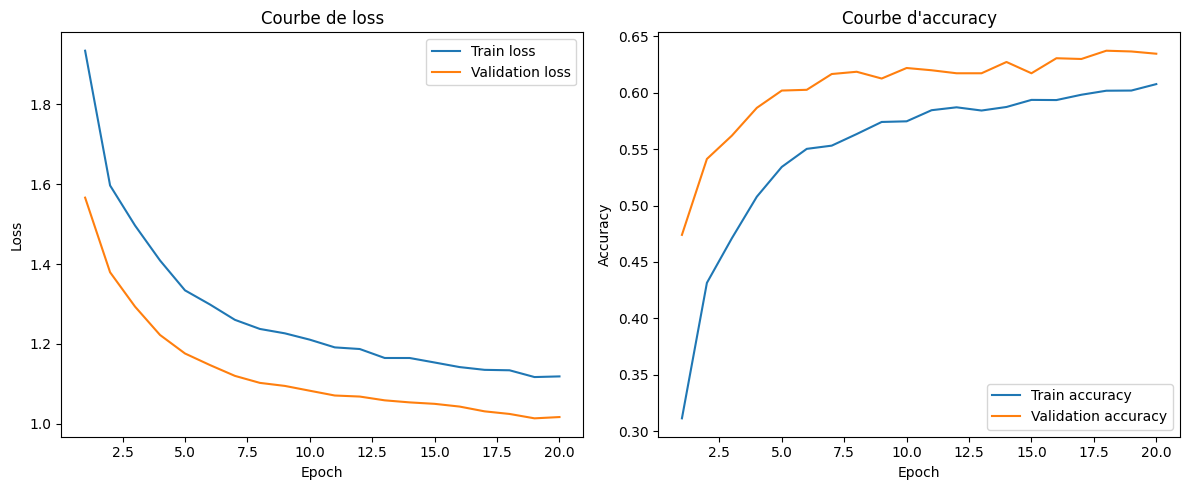

Courbe sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/MLPSequential_xavier_curves.png

Expérience : MLPCustom_gaussian
Epoch 01/20 | Train loss: 2.0391 | Val loss: 1.7237 | Val accuracy: 0.3600
Epoch 02/20 | Train loss: 1.6873 | Val loss: 1.5512 | Val accuracy: 0.4333
Epoch 03/20 | Train loss: 1.5687 | Val loss: 1.4429 | Val accuracy: 0.4840
Epoch 04/20 | Train loss: 1.4801 | Val loss: 1.3590 | Val accuracy: 0.5260
Epoch 05/20 | Train loss: 1.4142 | Val loss: 1.2863 | Val accuracy: 0.5660
Epoch 06/20 | Train loss: 1.3507 | Val loss: 1.2258 | Val accuracy: 0.5880
Epoch 07/20 | Train loss: 1.3057 | Val loss: 1.1915 | Val accuracy: 0.5920
Epoch 08/20 | Train loss: 1.2858 | Val loss: 1.1639 | Val accuracy: 0.6047
Epoch 09/20 | Train loss: 1.2518 | Val loss: 1.1424 | Val accuracy: 0.5967
Epoch 10/20 | Train loss: 1.2360 | Val loss: 1.1353 | Val accuracy: 0.6027
Epoch 11/20 | Train loss: 1.2256 | Val loss: 1.1106 | Val accuracy: 0.6047
Epoch 12/20 | Train loss: 1.2

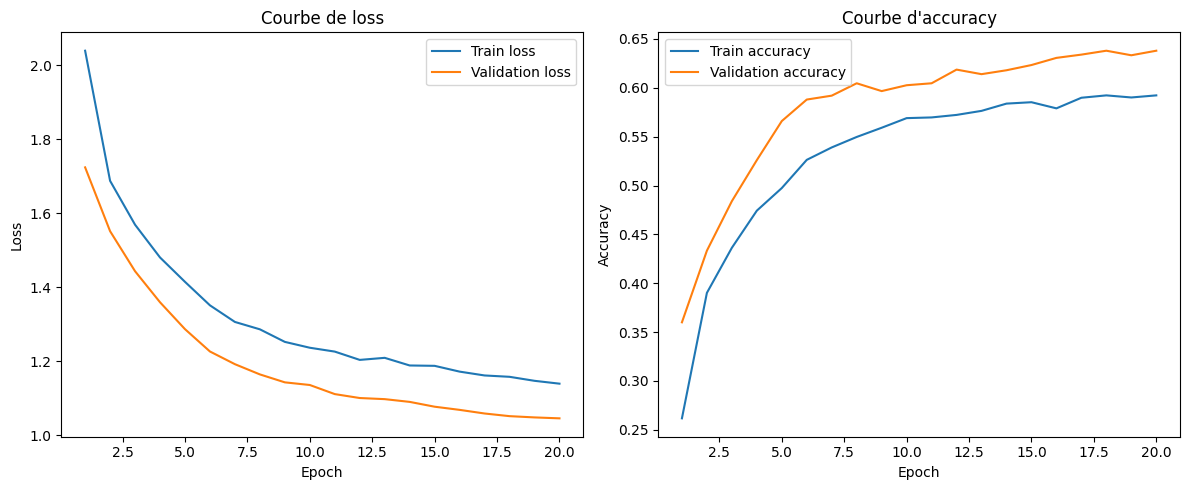

Courbe sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/MLPCustom_gaussian_curves.png

Expérience : MLPCustom_constant
Epoch 01/20 | Train loss: 2.2221 | Val loss: 2.1767 | Val accuracy: 0.1907
Epoch 02/20 | Train loss: 2.1680 | Val loss: 2.1307 | Val accuracy: 0.2280
Epoch 03/20 | Train loss: 2.0687 | Val loss: 1.9946 | Val accuracy: 0.2967
Epoch 04/20 | Train loss: 1.9330 | Val loss: 1.8241 | Val accuracy: 0.3853
Epoch 05/20 | Train loss: 1.7387 | Val loss: 1.5974 | Val accuracy: 0.5073
Epoch 06/20 | Train loss: 1.5309 | Val loss: 1.3473 | Val accuracy: 0.5573
Epoch 07/20 | Train loss: 1.3998 | Val loss: 1.2653 | Val accuracy: 0.5707
Epoch 08/20 | Train loss: 1.3393 | Val loss: 1.2143 | Val accuracy: 0.5793
Epoch 09/20 | Train loss: 1.3067 | Val loss: 1.1922 | Val accuracy: 0.6027
Epoch 10/20 | Train loss: 1.2864 | Val loss: 1.1733 | Val accuracy: 0.6020
Epoch 11/20 | Train loss: 1.2612 | Val loss: 1.1539 | Val accuracy: 0.6087
Epoch 12/20 | Train loss: 1.244

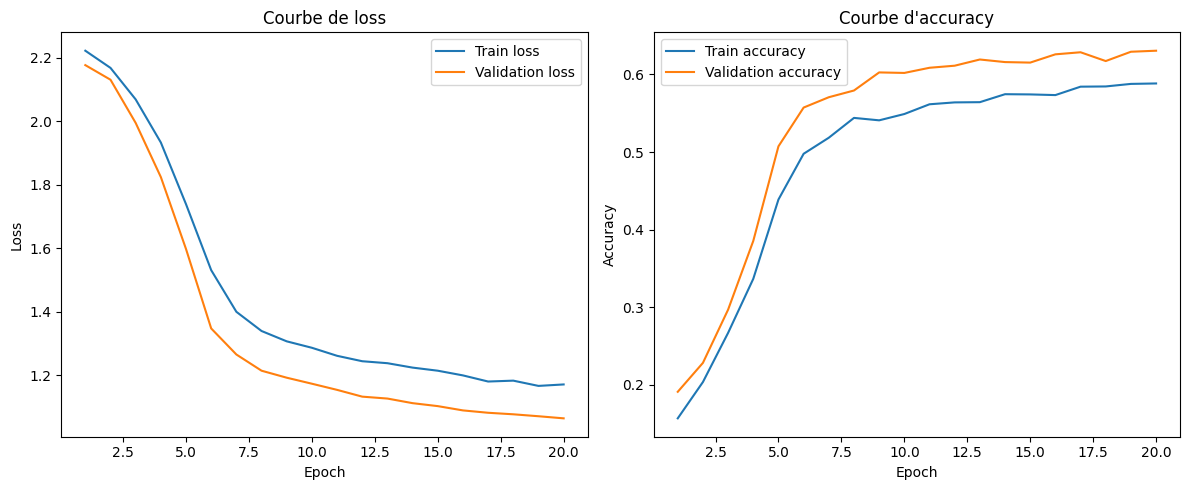

Courbe sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/MLPCustom_constant_curves.png

Expérience : MLPCustom_xavier
Epoch 01/20 | Train loss: 1.9247 | Val loss: 1.5404 | Val accuracy: 0.4700
Epoch 02/20 | Train loss: 1.5699 | Val loss: 1.3576 | Val accuracy: 0.5220
Epoch 03/20 | Train loss: 1.4440 | Val loss: 1.2570 | Val accuracy: 0.5707
Epoch 04/20 | Train loss: 1.3800 | Val loss: 1.2038 | Val accuracy: 0.5860
Epoch 05/20 | Train loss: 1.3348 | Val loss: 1.1655 | Val accuracy: 0.5993
Epoch 06/20 | Train loss: 1.2965 | Val loss: 1.1362 | Val accuracy: 0.6080
Epoch 07/20 | Train loss: 1.2699 | Val loss: 1.1222 | Val accuracy: 0.6053
Epoch 08/20 | Train loss: 1.2324 | Val loss: 1.1015 | Val accuracy: 0.6120
Epoch 09/20 | Train loss: 1.2095 | Val loss: 1.0903 | Val accuracy: 0.6213
Epoch 10/20 | Train loss: 1.2009 | Val loss: 1.0752 | Val accuracy: 0.6173
Epoch 11/20 | Train loss: 1.1802 | Val loss: 1.0630 | Val accuracy: 0.6233
Epoch 12/20 | Train loss: 1.1657 

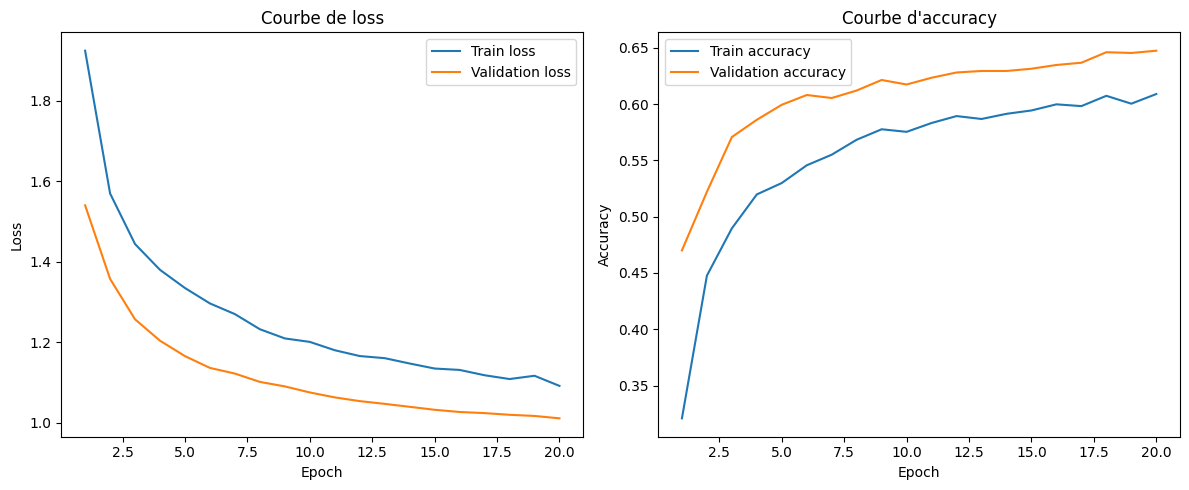

Courbe sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/MLPCustom_xavier_curves.png


,experiment,model_name,initialization,best_val_loss,best_val_accuracy,model_path,curve_path,epochs_trained
0,MLPSequential_gaussian,MLPSequential,gaussian,1.026364,0.641333,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,20
1,MLPSequential_constant,MLPSequential,constant,1.055725,0.625333,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,20
2,MLPSequential_xavier,MLPSequential,xavier,1.013707,0.636667,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,20
3,MLPCustom_gaussian,MLPCustom,gaussian,1.045097,0.638000,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,20
4,MLPCustom_constant,MLPCustom,constant,1.064221,0.630667,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,20
5,MLPCustom_xavier,MLPCustom,xavier,1.010873,0.647333,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,/content/drive/MyDrive/Projet_Deep_Learning_Mu...,20


In [11]:
experiments = [
    ("MLPSequential", MLPSequential, "gaussian"),
    ("MLPSequential", MLPSequential, "constant"),
    ("MLPSequential", MLPSequential, "xavier"),
    ("MLPCustom", MLPCustom, "gaussian"),
    ("MLPCustom", MLPCustom, "constant"),
    ("MLPCustom", MLPCustom, "xavier"),
]

criterion = nn.CrossEntropyLoss()
learning_rate = 0.001
num_epochs = 20
patience = 5

experiment_results = []

for model_name, model_class, init_method in experiments:
    experiment_name = f"{model_name}_{init_method}"

    print("\n" + "=" * 60)
    print("Expérience :", experiment_name)
    print("=" * 60)

    model = model_class(input_dim=input_dim, num_classes=num_classes)
    model = init_weights(model, method=init_method)
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model_save_path = os.path.join(MODEL_DIR, f"{experiment_name}_best.pt")
    curve_save_path = os.path.join(RESULTS_DIR, f"{experiment_name}_curves.png")

    history, best_val_loss, best_val_accuracy = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=num_epochs,
        patience=patience,
        save_path=model_save_path
    )

    plot_training_curves(history, curve_save_path)

    experiment_results.append({
        "experiment": experiment_name,
        "model_name": model_name,
        "initialization": init_method,
        "best_val_loss": best_val_loss,
        "best_val_accuracy": best_val_accuracy,
        "model_path": model_save_path,
        "curve_path": curve_save_path,
        "epochs_trained": len(history["train_loss"])
    })

results_df = pd.DataFrame(experiment_results)
display(results_df)

## 8. Évaluation finale

In [12]:
results_csv_path = os.path.join(RESULTS_DIR, "mlp_spotify_experiments_results.csv")
results_df.to_csv(results_csv_path, index=False)

print("Tableau comparatif sauvegardé :", results_csv_path)

best_index = results_df.sort_values(
    by=["best_val_accuracy", "best_val_loss"],
    ascending=[False, True]
).index[0]

best_experiment = results_df.loc[best_index]

print("Meilleure expérience :")
display(best_experiment)

best_model_name = best_experiment["model_name"]
best_model_path = best_experiment["model_path"]

if best_model_name == "MLPSequential":
    best_model = MLPSequential(input_dim=input_dim, num_classes=num_classes)
elif best_model_name == "MLPCustom":
    best_model = MLPCustom(input_dim=input_dim, num_classes=num_classes)
else:
    raise ValueError("Nom de modèle inconnu.")

best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model = best_model.to(device)

test_loss, test_accuracy, test_predictions, test_labels = evaluate(
    best_model,
    test_loader,
    criterion,
    device
)

test_precision = precision_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

print("Résultats sur le test set :")
print(f"Test loss      : {test_loss:.4f}")
print(f"Accuracy       : {test_accuracy:.4f}")
print(f"Precision macro: {test_precision:.4f}")
print(f"Recall macro   : {test_recall:.4f}")
print(f"F1-score macro : {test_f1:.4f}")

print("\nClassification report :")
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Tableau comparatif sauvegardé : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/mlp_spotify_experiments_results.csv
Meilleure expérience :


,5
experiment,MLPCustom_xavier
model_name,MLPCustom
initialization,xavier
best_val_loss,1.010873
best_val_accuracy,0.647333
model_path,/content/drive/MyDrive/Projet_Deep_Learning_Mu...
curve_path,/content/drive/MyDrive/Projet_Deep_Learning_Mu...
epochs_trained,20


Résultats sur le test set :
Test loss      : 1.0155
Accuracy       : 0.6160
Precision macro: 0.6116
Recall macro   : 0.6160
F1-score macro : 0.6080

Classification report :
              precision    recall  f1-score   support

    acoustic       0.46      0.42      0.44       150
    afrobeat       0.73      0.69      0.71       150
    alt-rock       0.33      0.25      0.28       150
 alternative       0.44      0.55      0.49       150
     ambient       0.81      0.77      0.79       150
       anime       0.52      0.54      0.53       150
 black-metal       0.89      0.88      0.89       150
   bluegrass       0.69      0.87      0.77       150
       blues       0.62      0.40      0.49       150
      brazil       0.63      0.79      0.70       150

    accuracy                           0.62      1500
   macro avg       0.61      0.62      0.61      1500
weighted avg       0.61      0.62      0.61      1500



<Figure size 1000x800 with 0 Axes>

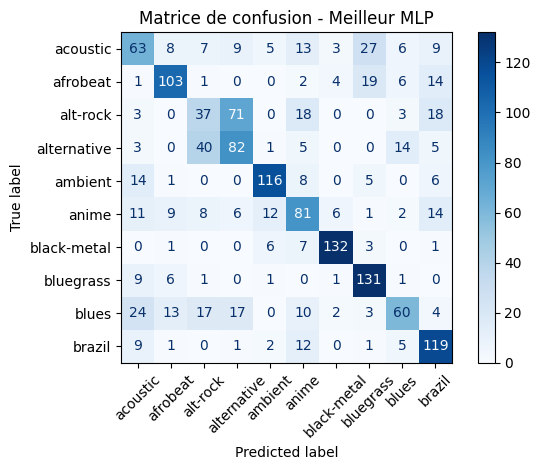

Matrice de confusion sauvegardée : /content/drive/MyDrive/Projet_Deep_Learning_Musique/results/mlp_spotify_confusion_matrix.png


In [13]:
cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.title("Matrice de confusion - Meilleur MLP")
plt.tight_layout()

confusion_matrix_path = os.path.join(RESULTS_DIR, "mlp_spotify_confusion_matrix.png")
plt.savefig(confusion_matrix_path, dpi=300)
plt.show()

print("Matrice de confusion sauvegardée :", confusion_matrix_path)

## 9. Inspection PyTorch du meilleur modèle

In [14]:
print("Paramètres nommés du modèle :")
for name, param in best_model.named_parameters():
    print(name, param.shape, "trainable =", param.requires_grad)

print("\nstate_dict du modèle :")
# state_dict contient les poids et biais appris par le modèle.
for key, value in best_model.state_dict().items():
    print(key, value.shape)

total_trainable_params = sum(
    param.numel()
    for param in best_model.parameters()
    if param.requires_grad
)

print("\nNombre total de paramètres entraînables :", total_trainable_params)

model_device = next(best_model.parameters()).device
print("Device utilisé par le modèle :", model_device)

# Le device cuda/cpu permet d'utiliser le GPU si disponible, sinon le processeur.
# Le meilleur modèle est sauvegardé pour pouvoir le recharger sans refaire tout l'entraînement.

Paramètres nommés du modèle :
fc1.weight torch.Size([128, 11]) trainable = True
fc1.bias torch.Size([128]) trainable = True
fc2.weight torch.Size([64, 128]) trainable = True
fc2.bias torch.Size([64]) trainable = True
fc3.weight torch.Size([10, 64]) trainable = True
fc3.bias torch.Size([10]) trainable = True

state_dict du modèle :
fc1.weight torch.Size([128, 11])
fc1.bias torch.Size([128])
fc2.weight torch.Size([64, 128])
fc2.bias torch.Size([64])
fc3.weight torch.Size([10, 64])
fc3.bias torch.Size([10])

Nombre total de paramètres entraînables : 10442
Device utilisé par le modèle : cuda:0
